   seed  mean_price_a  mean_price_b  colluding       poa
0     0      1.400252      1.409190      False  0.996831
1     1      1.399661      1.394776      False  1.006680
2     2      1.390843      1.399383      False  0.997998
3     3      1.396240      1.403766      False  1.000755
4     4      1.401013      1.390561      False  1.009152

Mean converged price: 1.3976 +/- 0.0052 (95% CI)
Mean PoA: 1.0023 +/- 0.0067 (95% CI)
Supra-Nash t-test: t=-1.278, p=0.8648
Collusion detected in 0/5 seeds


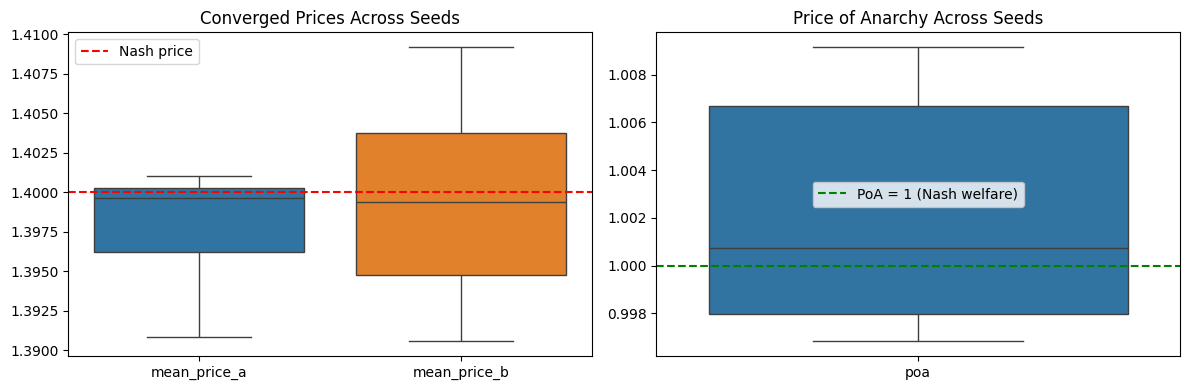

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------
# 1. Collusion detection heuristic
# ---------------------------------------------------------
def is_colluding(prices, nash_p, threshold=1.05, window=50):
    """
    Flags collusion if mean price over the last `window` rounds
    exceeds `threshold` * nash_p (Calvano et al. use 5% above Nash).
    """
    return np.mean(prices[-window:]) > nash_p * threshold


def is_colluding_strict(prices_a, prices_b, nash_p, threshold=1.05, window=50):
    """
    Stricter version per pitfalls list: requires BOTH firms pricing
    above Nash for N >= 50 CONSECUTIVE rounds (not just mean over window).
    """
    above_a = np.array(prices_a[-window:]) > nash_p * threshold
    above_b = np.array(prices_b[-window:]) > nash_p * threshold
    both_above = above_a & above_b
    return both_above.all()  # all rounds in window must satisfy


# ---------------------------------------------------------
# 2. Price of Anarchy metric
# ---------------------------------------------------------
def price_of_anarchy(welfare_competitive, welfare_nash):
    """
    PoA = social welfare under (learned) competitive outcome / welfare under Nash.
    PoA < 1 implies welfare loss relative to Nash (higher prices, lower output).
    Note: PoA measures WELFARE, not individual firm profit.
    """
    return welfare_competitive / welfare_nash


def social_welfare(prices, quantities, costs):
    """
    Total welfare = consumer surplus + producer surplus.
    Simplified here as total profit + a proxy consumer surplus term;
    adapt to your exact demand model from Weeks 1-4.
    """
    producer_surplus = np.sum((np.array(prices) - np.array(costs)) * np.array(quantities))
    return producer_surplus  # extend with CS term if your model computes it


# ---------------------------------------------------------
# 3. Multi-seed statistical analysis (REQUIRED: 5+ seeds, CIs)
# ---------------------------------------------------------
def run_multi_seed_analysis(seeds=[0, 1, 2, 3, 4], nash_p=1.4):
    """
    Placeholder loop structure — replace the inner call with
    your actual Week 5 self-play training + price extraction.
    """
    results = []

    for seed in seeds:
        np.random.seed(seed)

        # === REPLACE THIS BLOCK with your actual trained agent rollout ===
        # e.g. prices_a, prices_b, welfare_c, welfare_n = run_trained_agents(seed)
        prices_a = np.random.normal(1.4, 0.05, 500)   # placeholder
        prices_b = np.random.normal(1.4, 0.05, 500)   # placeholder
        welfare_competitive = social_welfare(prices_a, np.ones(500)*0.5, np.ones(500)*1.0)
        welfare_nash = social_welfare(np.ones(500)*nash_p, np.ones(500)*0.5, np.ones(500)*1.0)
        # ===================================================================

        colluding = is_colluding_strict(prices_a, prices_b, nash_p)
        poa = price_of_anarchy(welfare_competitive, welfare_nash)

        results.append({
            "seed": seed,
            "mean_price_a": np.mean(prices_a[-50:]),
            "mean_price_b": np.mean(prices_b[-50:]),
            "colluding": colluding,
            "poa": poa
        })

    df = pd.DataFrame(results)
    return df


def summarize_with_ci(df, col, confidence=0.95):
    """Mean +/- 95% CI using t-distribution (per StatQuest method)."""
    n = len(df)
    mean = df[col].mean()
    sem = stats.sem(df[col])
    ci = sem * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean, ci


# ---------------------------------------------------------
# 4. Hypothesis test: is mean price statistically > Nash?
# ---------------------------------------------------------
def test_supra_nash(df, nash_p):
    """One-sample t-test: H0: mean price == nash_p, H1: mean price > nash_p."""
    t_stat, p_value = stats.ttest_1samp(df["mean_price_a"], nash_p, alternative="greater")
    return t_stat, p_value


# ---------------------------------------------------------
# 5. Plots (price trajectory + profit box plot)
# ---------------------------------------------------------
def plot_results(df, nash_p):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot of mean prices across seeds vs Nash
    sns.boxplot(data=df[["mean_price_a", "mean_price_b"]], ax=axes[0])
    axes[0].axhline(nash_p, color="red", linestyle="--", label="Nash price")
    axes[0].set_title("Converged Prices Across Seeds")
    axes[0].legend()

    # PoA across seeds
    sns.boxplot(data=df[["poa"]], ax=axes[1])
    axes[1].axhline(1.0, color="green", linestyle="--", label="PoA = 1 (Nash welfare)")
    axes[1].set_title("Price of Anarchy Across Seeds")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("results/week6_summary_plots.png", dpi=150)
    plt.show()


if __name__ == "__main__":
    NASH_PRICE = 1.4  # replace with your actual computed Nash price from earlier weeks

    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)

    df = run_multi_seed_analysis(seeds=[0, 1, 2, 3, 4], nash_p=NASH_PRICE)
    print(df)

    mean_price, ci = summarize_with_ci(df, "mean_price_a")
    mean_poa, poa_ci = summarize_with_ci(df, "poa")
    t_stat, p_val = test_supra_nash(df, NASH_PRICE)

    print(f"\nMean converged price: {mean_price:.4f} +/- {ci:.4f} (95% CI)")
    print(f"Mean PoA: {mean_poa:.4f} +/- {poa_ci:.4f} (95% CI)")
    print(f"Supra-Nash t-test: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"Collusion detected in {df['colluding'].sum()}/{len(df)} seeds")

    df.to_csv("results/week6_seed_results.csv", index=False)
    plot_results(df, NASH_PRICE)